### Importing Libraries 

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## Reading Data

In [35]:
df = pd.read_csv("student-scores.csv")
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [36]:
### Droping Unwanted Features 
df.drop(['id', 'first_name', 'last_name', 'email'], axis=1,inplace=True)

In [37]:
df.isnull().sum()

gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [38]:
df.describe()

,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
std,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
min,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
25%,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000
50%,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000
75%,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000
max,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   gender                      2000 non-null   object
 1   part_time_job               2000 non-null   bool  
 2   absence_days                2000 non-null   int64 
 3   extracurricular_activities  2000 non-null   bool  
 4   weekly_self_study_hours     2000 non-null   int64 
 5   career_aspiration           2000 non-null   object
 6   math_score                  2000 non-null   int64 
 7   history_score               2000 non-null   int64 
 8   physics_score               2000 non-null   int64 
 9   chemistry_score             2000 non-null   int64 
 10  biology_score               2000 non-null   int64 
 11  english_score               2000 non-null   int64 
 12  geography_score             2000 non-null   int64 
dtypes: bool(2), int64(9), object(2)
memory usage: 17

In [68]:
### Hishest Score in Each subject
subject=['math_score', 'history_score',	'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
highest_score=[]
for i in subject:
    highest_score.append(df[i].max())
highest_score

[100, 100, 100, 100, 100, 99, 100]

In [41]:
## Target calumn
df["final_score"] = (df["biology_score"] + df["chemistry_score"] + df["english_score"] + df["geography_score"] + df ["history_score"] + df["math_score"] + df["physics_score"] ) / 7

## EDA 

C:\Users\User\AppData\Local\Temp\ipykernel_23616\1738794667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette=custom_colors)


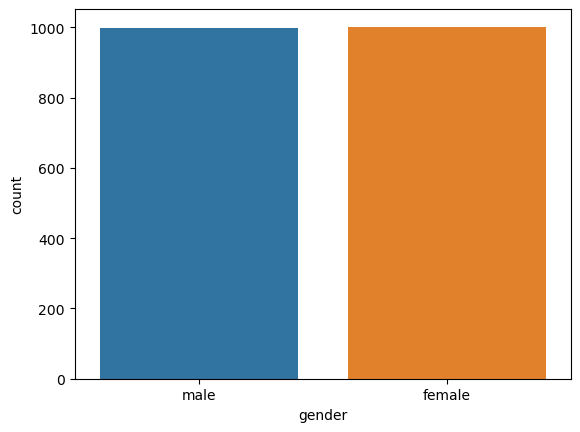

In [42]:
custom_colors = {'male': '#1f77b4', 'female': '#ff7f0e'}  # dictionary mapping
sns.countplot(x='gender', data=df, palette=custom_colors)
plt.show()

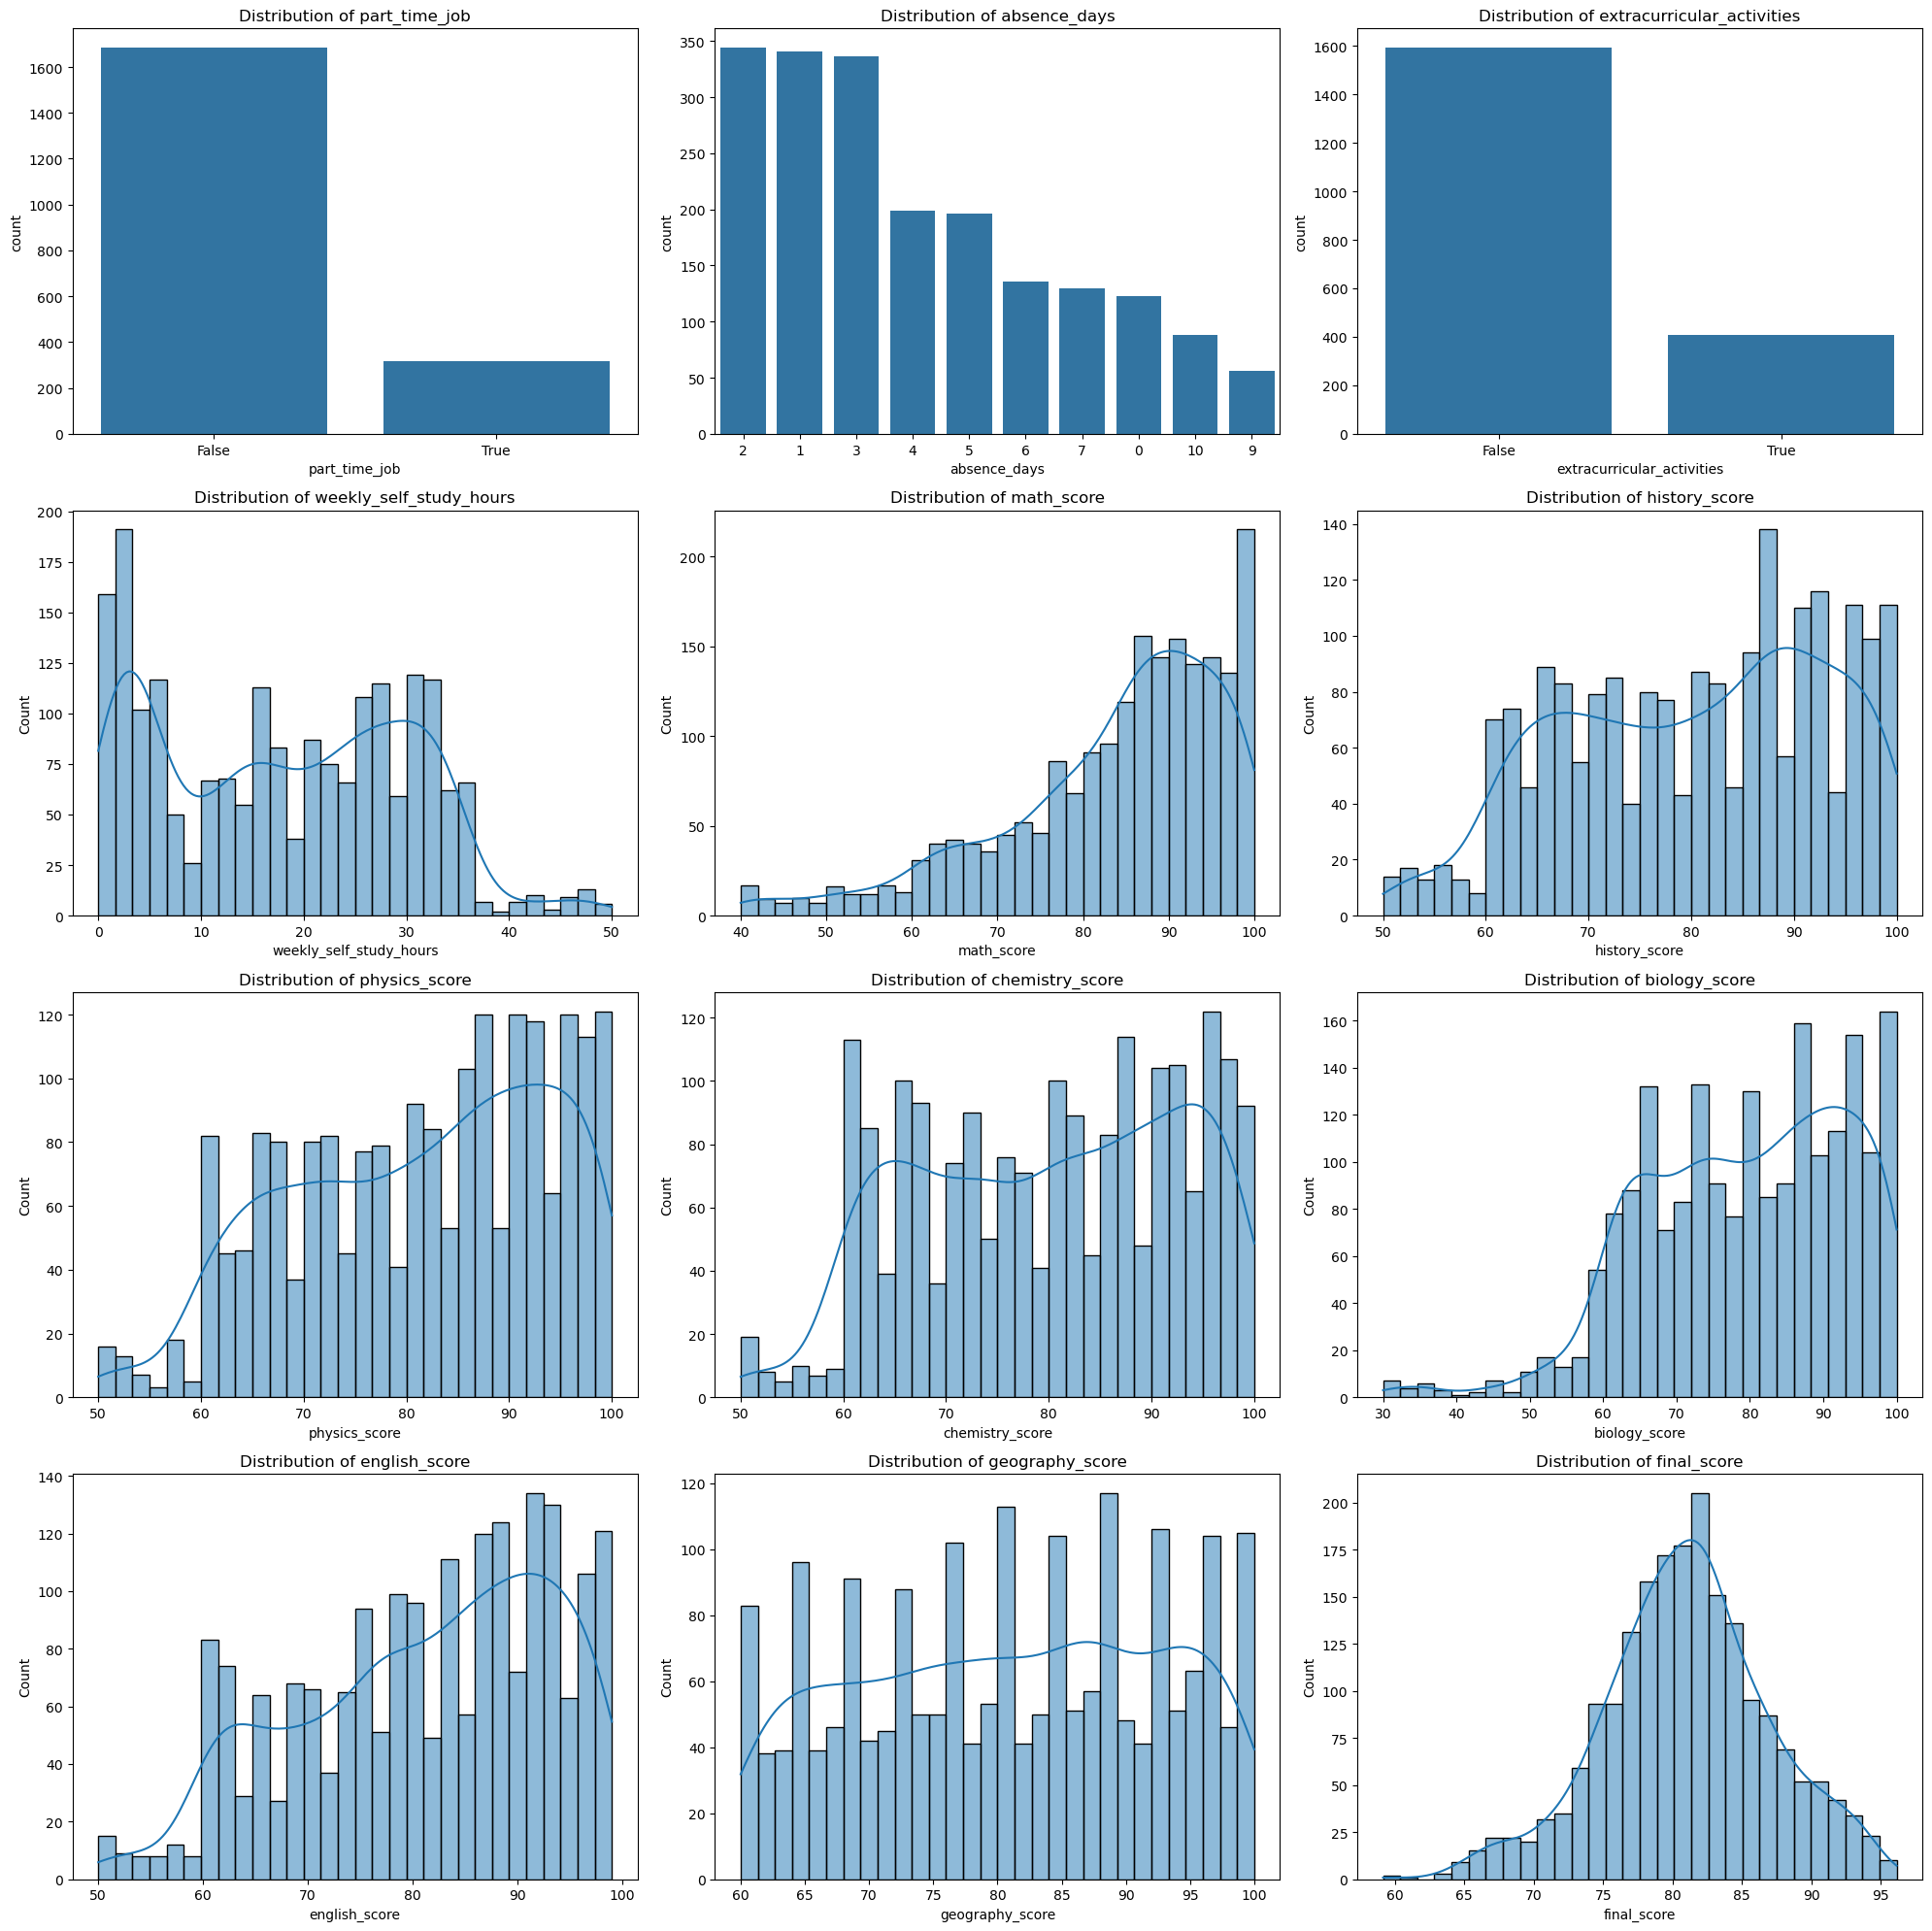

In [43]:
## Ploting discrite and countenues Numerical columns
numeric_cols = df.select_dtypes(exclude='object').columns .tolist()
n_rows = (len(numeric_cols)) // 3  # Round up division

fig,axes = plt.subplots(n_rows, 3, figsize=(20, 5 * n_rows))
axes = axes.flatten()  
for i,col  in enumerate(numeric_cols):
    if df[col].nunique()<20:
        sns.countplot(data=df,x=col,ax=axes[i],order=df[col].value_counts().index[:10])
    else:  # Treat as continuous
        sns.histplot(data=df, x=col, ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

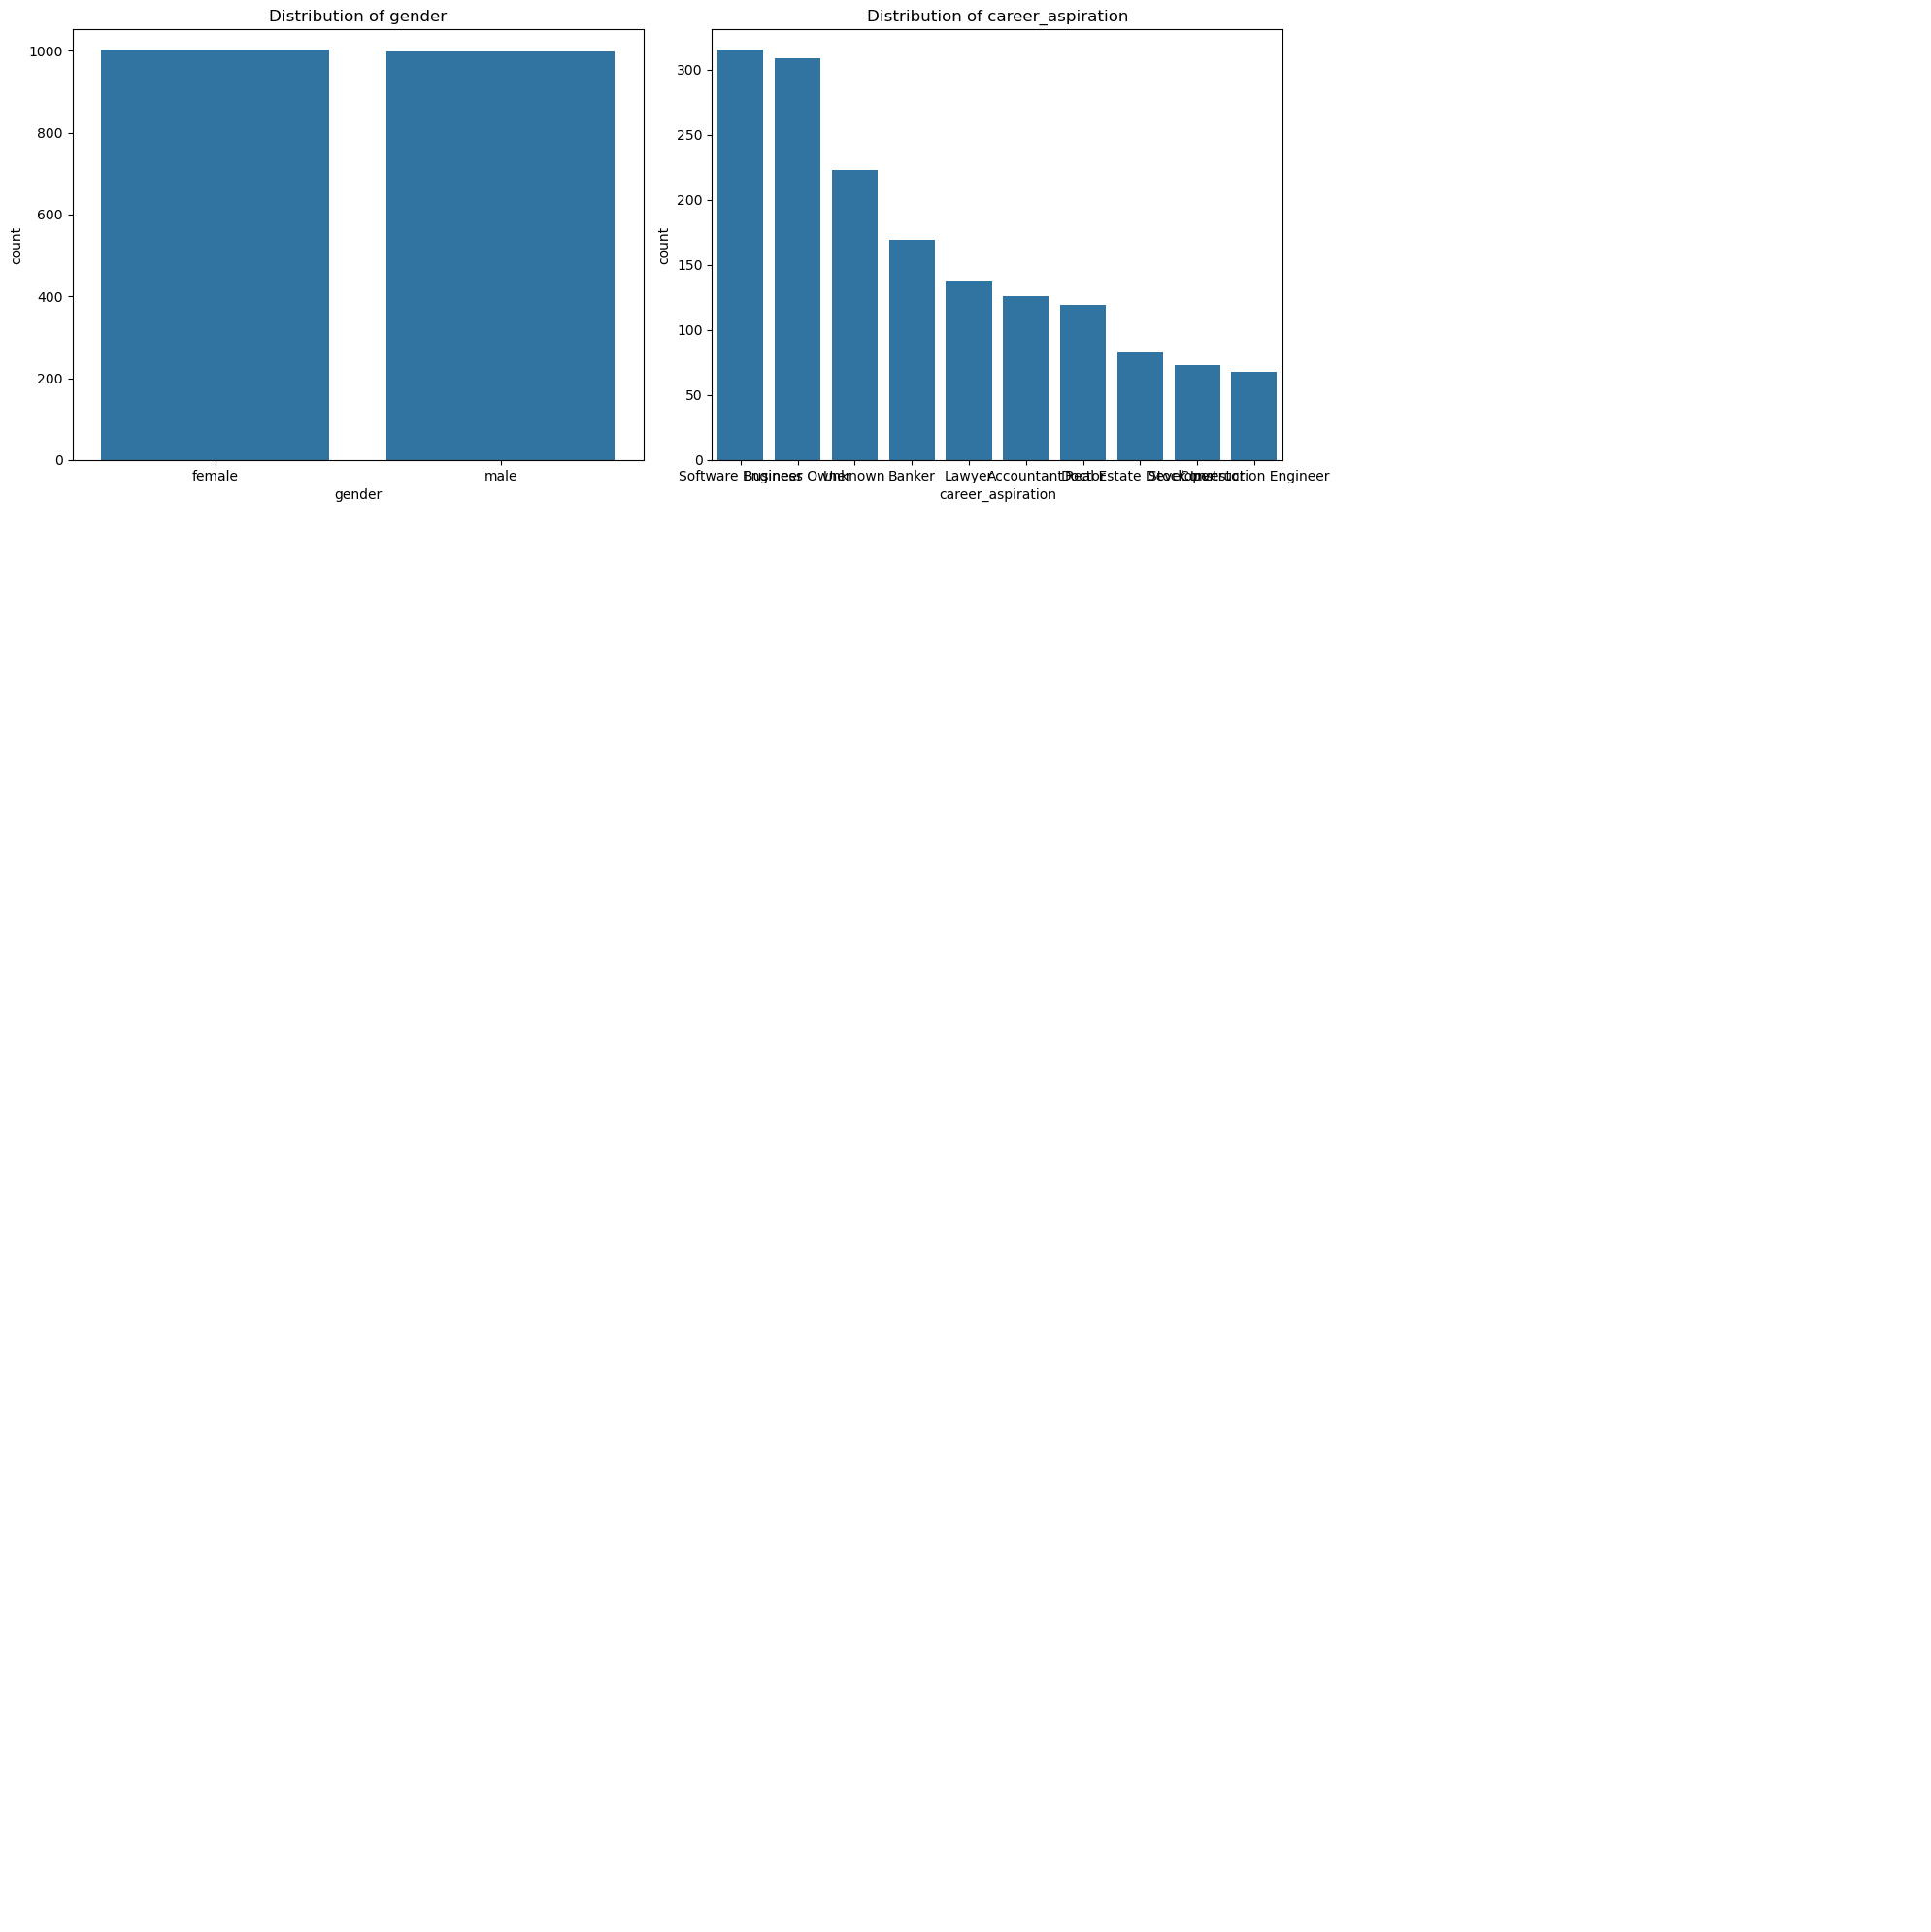

In [44]:
## Oblect Datatype
## Ploting discrite and countenues Numerical columns
object_col = df.select_dtypes(include='object').columns .tolist()
n_rows = (len(numeric_cols)+2) // 3  # Round up division

fig,axes = plt.subplots(n_rows, 3, figsize=(20, 5 * n_rows))
axes = axes.flatten()  
for i,col  in enumerate(object_col):
    if df[col].nunique()<20:
        sns.countplot(data=df,x=col,ax=axes[i],order=df[col].value_counts().index[:10])
    else:  # Treat as continuous
        sns.histplot(data=df, x=col, ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'Distribution of {col}')
# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

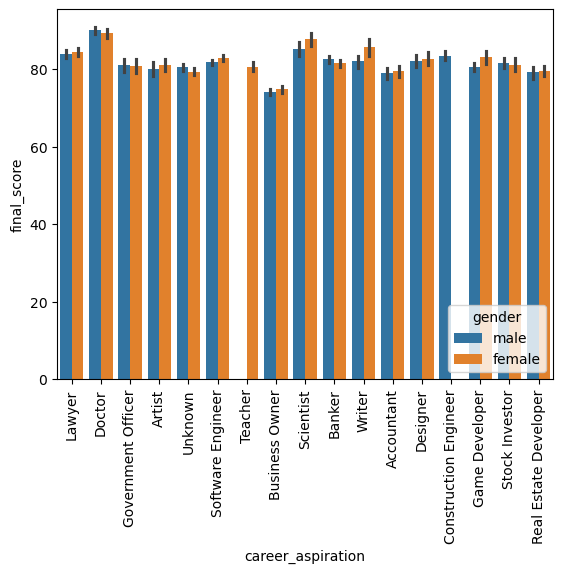

In [45]:
sns.barplot(data=df,x='career_aspiration',y='final_score',hue='gender')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='weekly_self_study_hours', ylabel='final_score'>

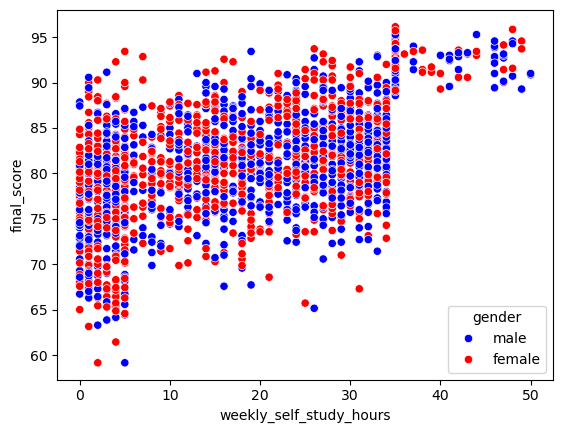

In [46]:
sns.scatterplot(
    data=df,
    x="weekly_self_study_hours",
    y="final_score",
    hue="gender",
    palette={"male": "blue", "female": "red"}
)


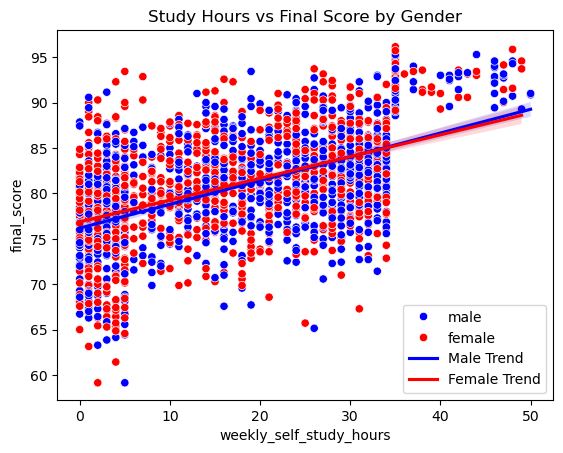

In [47]:
sns.scatterplot(
    data=df,
    x="weekly_self_study_hours",
    y="final_score",
    hue="gender",                # color points by gender
    palette={"male": "blue", "female": "red"}
)

sns.regplot(
    data=df[df["gender"]=="male"],
    x="weekly_self_study_hours",
    y="final_score",
    scatter=False,
    color="blue",
    label="Male Trend"
)

sns.regplot(
    data=df[df["gender"]=="female"],
    x="weekly_self_study_hours",
    y="final_score",
    scatter=False,
    color="red",
    label="Female Trend"
)

plt.title("Study Hours vs Final Score by Gender")
plt.legend()
plt.show()


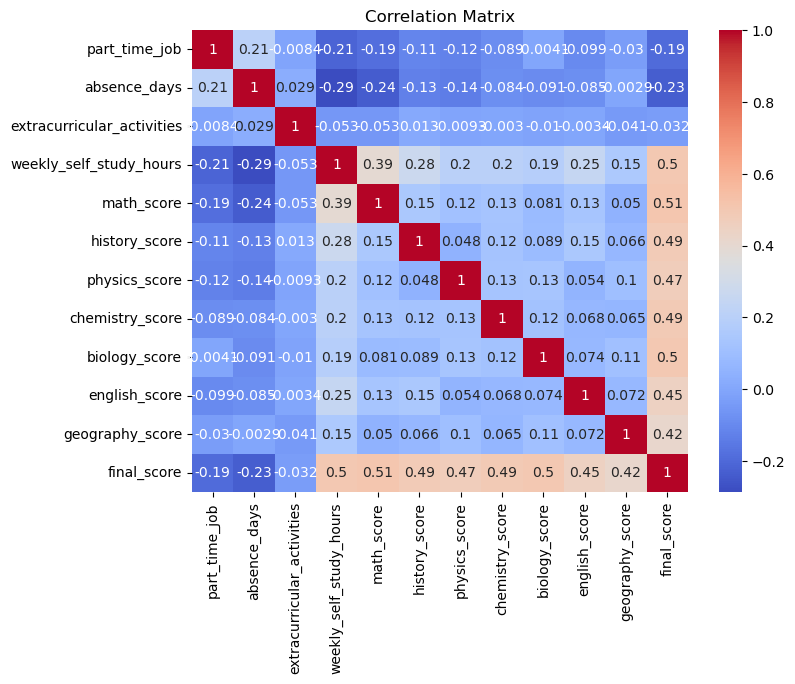

In [48]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Feature-Engineering¶


In [49]:
onehot_encode = {}
for col in object_col:
    onehot = OneHotEncoder(sparse_output=False,drop='first')
    df[col] = onehot.fit_transform(df[[col]])
    onehot_encode[col] = onehot

In [50]:
onehot_encode

{'gender': OneHotEncoder(drop='first', sparse_output=False),
 'career_aspiration': OneHotEncoder(drop='first', sparse_output=False)}

In [51]:
## Converting Boolen Columns to Inter or numerical columns
df['part_time_job'] = df['part_time_job'].astype(int)
df['extracurricular_activities'] = df['extracurricular_activities'].astype(int)

In [52]:
df

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,final_score
0,1.0,0,3,0,27,0.0,73,81,93,97,63,80,87,82.000000
1,0.0,0,2,0,47,0.0,90,86,96,100,90,88,90,91.428571
2,0.0,0,9,1,13,0.0,81,97,95,96,65,77,94,86.428571
3,0.0,0,5,0,3,1.0,71,74,88,80,89,63,86,78.714286
4,1.0,0,5,0,10,0.0,84,77,65,65,80,74,76,74.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.0,0,2,0,30,0.0,83,77,84,73,75,84,82,79.714286
1996,1.0,0,2,0,20,0.0,89,65,73,80,87,67,73,76.285714
1997,0.0,0,5,0,14,0.0,97,85,63,93,68,94,78,82.571429
1998,0.0,1,10,1,5,0.0,51,96,72,89,95,88,75,80.857143


## Spling and Standard Scaling  of Features

In [53]:
# Split first (important to avoid data leakage)
X = df.drop("final_score", axis=1)  
y = df["final_score"]           

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)        

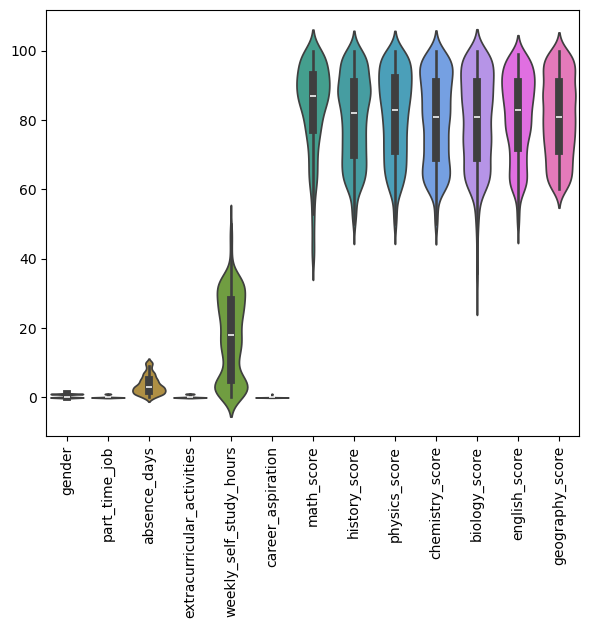

In [54]:
### ViolinPlot Before Scaling
sns.violinplot(X_train)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

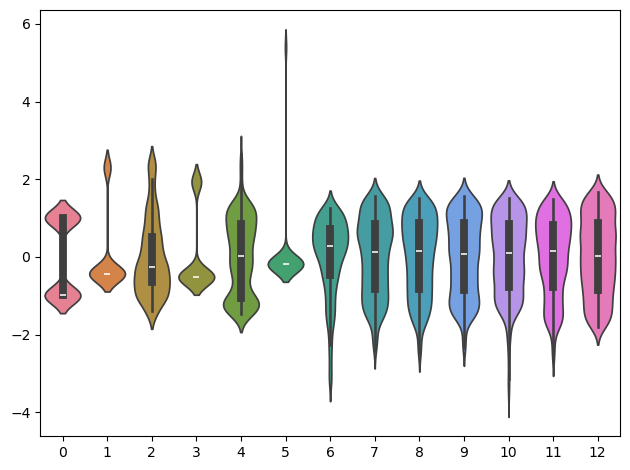

In [55]:
### ViolinPlot Before Scaling

sns.violinplot(X_train_scaled)
plt.tight_layout()

## Training Of model with Only weekly_self_study_hours(Linear Regression model)

In [64]:
X = df[['weekly_self_study_hours']]
y = df["final_score"]           

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)        

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Train linear model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Predict
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluate
#mse_linear = accuracy_score(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
mae = mean_absolute_error(y_test, y_pred_linear) 
r2 = r2_score(y_test, y_pred_linear)
rmse = np.sqrt(mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 4.544466663394534
RMSE: 5.630826164380863
MSE: 31.7062032934761
R² Score: 0.26175353171328386


### Making Prediction 

In [69]:
study_hours = [[4]]
study_hours_scaled = scaler.transform(study_hours)
predicted_score = linear_model.predict(study_hours_scaled)
print(predicted_score[0])

77.52803718627096


C:\Users\User\anaconda3\envs\Ml-env\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [58]:
print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_)


Intercept: 80.89616071428571
Coefficient: [2.93288071]


## Train Of Model On a Mult Columns with Random Forest model

In [59]:
X = df.drop("final_score", axis=1)  
y = df["final_score"]           
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)        

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Train linear model
model = RandomForestRegressor()
model.fit(X_train_scaled, y_train)

# Predict
y_pred =model.predict(X_test_scaled)

# Evaluate
#mse_linear = accuracy_score(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred) 
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 1.2956607142857106
RMSE: 1.7907664545936592
MSE: 3.206844494897944
R² Score: 0.9253319105794596


In [60]:
## Feature Importence with Randomforest
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print(importance_df.sort_values(by='Importance', ascending=False))

                       Feature  Importance
4      weekly_self_study_hours    0.230444
6                   math_score    0.176735
10               biology_score    0.143882
9              chemistry_score    0.103636
7                history_score    0.098915
8                physics_score    0.087976
11               english_score    0.076376
12             geography_score    0.070754
2                 absence_days    0.007140
0                       gender    0.001516
3   extracurricular_activities    0.001141
1                part_time_job    0.001086
5            career_aspiration    0.000399
